In [1]:
import pandas as pd
pd.options.mode.chained_assignment = None
import pylab as pl
import numpy as np
import scipy.optimize as opt
from sklearn import preprocessing
%matplotlib inline 
import matplotlib.pyplot as plt

In [2]:
patients_data = pd.read_csv("plan b data.csv", index_col=0)

In [3]:
patients_data

,Diagnosis,VisualG,SUVmax,TBR,ConclusionPET,ABusepostoper,minimum_intensity,maximum_intensity,range,mean_intensity,...,gray_level_nonuniformity_A,size_zone_nonuniformity,zone_percentage,low_gray_level_zone_emphasis,high_gray_level_zone_emphasis,small_zone_low_gray_level_emphasis,small_zone_high_gray_level_emphasis,large_zone_low_gray_level_emphasis,large_zone_high_gray_level_emphasis,filter_$
Patients,,,,,,,,,,,,,,,,,,,,,
1,1,4,6.7,3.72,2,1,0.62,6.68,6.07,2.34,...,16.08,25.22,0.00,0.23,9.939963e+07,0.01,9.860538e+07,11.75,1.229531e+08,0
2,1,3,9.8,4.90,1,1,0.34,9.66,9.32,2.61,...,68.59,37.58,0.00,0.40,2.941573e+08,0.01,2.939368e+08,28.57,3.034294e+08,0
3,1,3,5.3,4.42,1,1,0.08,5.28,5.20,1.72,...,20.20,18.46,0.00,0.36,1.688961e+09,0.03,1.688835e+09,10.02,1.691300e+09,0
4,1,4,11.2,10.18,1,1,0.47,8.50,8.03,2.21,...,11.73,8.39,0.00,0.29,1.263940e+07,0.01,1.259057e+07,31.82,1.366822e+07,0
5,1,4,9.1,6.59,1,1,0.60,8.30,7.70,2.71,...,10.32,5.95,0.00,0.36,1.278671e+07,0.01,1.277919e+07,31.71,1.305688e+07,0
6,1,4,6.3,3.94,1,1,0.70,6.28,5.58,2.70,...,6.46,7.92,0.00,0.33,3.082371e+06,0.01,3.017416e+06,23.82,5.376431e+06,0
7,1,4,4.9,4.45,1,1,0.48,4.87,4.39,1.70,...,7.19,11.14,0.00,0.25,7.772283e+07,0.02,7.742148e+07,9.02,8.304376e+07,0
8,1,4,6.1,4.69,1,1,0.82,6.11,5.29,2.36,...,2.59,3.77,0.00,0.21,1.662223e+06,0.01,1.625534e+06,12.66,2.738375e+06,0
9,1,3,10.3,2.86,1,1,0.44,6.76,6.32,3.01,...,43.75,30.46,0.02,0.35,1.049818e+04,0.03,3.211200e+02,15.54,4.590263e+05,0


In [4]:
#In practice, feature selection should be done after data pre-processing, so ideally, all the categorical variables are encoded into numbers
numerics = ['int16','int32','int64','float16','float32','float64']
numerical_vars = list(patients_data.select_dtypes(include=numerics).columns)
patients_data = patients_data[numerical_vars]
patients_data

,Diagnosis,VisualG,SUVmax,TBR,ConclusionPET,ABusepostoper,minimum_intensity,maximum_intensity,range,mean_intensity,...,gray_level_nonuniformity_A,size_zone_nonuniformity,zone_percentage,low_gray_level_zone_emphasis,high_gray_level_zone_emphasis,small_zone_low_gray_level_emphasis,small_zone_high_gray_level_emphasis,large_zone_low_gray_level_emphasis,large_zone_high_gray_level_emphasis,filter_$
Patients,,,,,,,,,,,,,,,,,,,,,
1,1,4,6.7,3.72,2,1,0.62,6.68,6.07,2.34,...,16.08,25.22,0.00,0.23,9.939963e+07,0.01,9.860538e+07,11.75,1.229531e+08,0
2,1,3,9.8,4.90,1,1,0.34,9.66,9.32,2.61,...,68.59,37.58,0.00,0.40,2.941573e+08,0.01,2.939368e+08,28.57,3.034294e+08,0
3,1,3,5.3,4.42,1,1,0.08,5.28,5.20,1.72,...,20.20,18.46,0.00,0.36,1.688961e+09,0.03,1.688835e+09,10.02,1.691300e+09,0
4,1,4,11.2,10.18,1,1,0.47,8.50,8.03,2.21,...,11.73,8.39,0.00,0.29,1.263940e+07,0.01,1.259057e+07,31.82,1.366822e+07,0
5,1,4,9.1,6.59,1,1,0.60,8.30,7.70,2.71,...,10.32,5.95,0.00,0.36,1.278671e+07,0.01,1.277919e+07,31.71,1.305688e+07,0
6,1,4,6.3,3.94,1,1,0.70,6.28,5.58,2.70,...,6.46,7.92,0.00,0.33,3.082371e+06,0.01,3.017416e+06,23.82,5.376431e+06,0
7,1,4,4.9,4.45,1,1,0.48,4.87,4.39,1.70,...,7.19,11.14,0.00,0.25,7.772283e+07,0.02,7.742148e+07,9.02,8.304376e+07,0
8,1,4,6.1,4.69,1,1,0.82,6.11,5.29,2.36,...,2.59,3.77,0.00,0.21,1.662223e+06,0.01,1.625534e+06,12.66,2.738375e+06,0
9,1,3,10.3,2.86,1,1,0.44,6.76,6.32,3.01,...,43.75,30.46,0.02,0.35,1.049818e+04,0.03,3.211200e+02,15.54,4.590263e+05,0


In [5]:
patients_data.isnull().sum()

Diagnosis                              0
VisualG                                0
SUVmax                                 0
TBR                                    0
ConclusionPET                          0
                                      ..
small_zone_low_gray_level_emphasis     0
small_zone_high_gray_level_emphasis    0
large_zone_low_gray_level_emphasis     0
large_zone_high_gray_level_emphasis    0
filter_$                               0
Length: 107, dtype: int64

In [6]:
X = patients_data.drop(['Diagnosis'], axis=1)
X

,VisualG,SUVmax,TBR,ConclusionPET,ABusepostoper,minimum_intensity,maximum_intensity,range,mean_intensity,quantile0025,...,gray_level_nonuniformity_A,size_zone_nonuniformity,zone_percentage,low_gray_level_zone_emphasis,high_gray_level_zone_emphasis,small_zone_low_gray_level_emphasis,small_zone_high_gray_level_emphasis,large_zone_low_gray_level_emphasis,large_zone_high_gray_level_emphasis,filter_$
Patients,,,,,,,,,,,,,,,,,,,,,
1,4,6.7,3.72,2,1,0.62,6.68,6.07,2.34,1.13,...,16.08,25.22,0.00,0.23,9.939963e+07,0.01,9.860538e+07,11.75,1.229531e+08,0
2,3,9.8,4.90,1,1,0.34,9.66,9.32,2.61,0.96,...,68.59,37.58,0.00,0.40,2.941573e+08,0.01,2.939368e+08,28.57,3.034294e+08,0
3,3,5.3,4.42,1,1,0.08,5.28,5.20,1.72,0.32,...,20.20,18.46,0.00,0.36,1.688961e+09,0.03,1.688835e+09,10.02,1.691300e+09,0
4,4,11.2,10.18,1,1,0.47,8.50,8.03,2.21,0.78,...,11.73,8.39,0.00,0.29,1.263940e+07,0.01,1.259057e+07,31.82,1.366822e+07,0
5,4,9.1,6.59,1,1,0.60,8.30,7.70,2.71,0.99,...,10.32,5.95,0.00,0.36,1.278671e+07,0.01,1.277919e+07,31.71,1.305688e+07,0
6,4,6.3,3.94,1,1,0.70,6.28,5.58,2.70,1.17,...,6.46,7.92,0.00,0.33,3.082371e+06,0.01,3.017416e+06,23.82,5.376431e+06,0
7,4,4.9,4.45,1,1,0.48,4.87,4.39,1.70,0.89,...,7.19,11.14,0.00,0.25,7.772283e+07,0.02,7.742148e+07,9.02,8.304376e+07,0
8,4,6.1,4.69,1,1,0.82,6.11,5.29,2.36,1.09,...,2.59,3.77,0.00,0.21,1.662223e+06,0.01,1.625534e+06,12.66,2.738375e+06,0
9,3,10.3,2.86,1,1,0.44,6.76,6.32,3.01,0.98,...,43.75,30.46,0.02,0.35,1.049818e+04,0.03,3.211200e+02,15.54,4.590263e+05,0


In [7]:
y = np.asarray(patients_data[['Diagnosis']])
y

array([[1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0]])

In [8]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LinearRegression
# Sequential Forward Selection(sfs)
sfs = SFS(LinearRegression(),
          k_features=20,
          forward=True,
          floating=False,
          scoring = 'r2',
          cv = 0)

In [9]:
sfs.fit(X, y)
sfs.k_feature_names_ 

('VisualG',
 'ConclusionPET',
 'ABusepostoper',
 'median_intensity',
 'variance',
 'cluster_prominence_mean',
 'cluster_prominence_max',
 'cluster_tendency_mean',
 'dissimilarity_mean',
 'energy_A',
 'information_measure_of_correlation2_mean',
 'inverse_difference_normalized_mean',
 'inverse_difference_normalized_max',
 'short_run_high_gray_level_emphasis_mean',
 'long_run_low_gray_level_emphasis_mean',
 'gray_level_nonuniformity_A',
 'low_gray_level_zone_emphasis',
 'high_gray_level_zone_emphasis',
 'small_zone_low_gray_level_emphasis',
 'filter_$')

In [10]:
#using the optimal value of k_features argument in both forward selection and backward elimination. In order to find out the optimal number of significant features
sfs1 = SFS(LinearRegression(),
         k_features=(3,50),
         forward=True,
         floating=False,
         cv=0)
sfs1.fit(X, y)

SequentialFeatureSelector(cv=0, estimator=LinearRegression(),
                          k_features=(3, 50))

/Users/Hanaly/anaconda3/lib/python3.6/site-packages/numpy/core/_methods.py:234: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims)
/Users/Hanaly/anaconda3/lib/python3.6/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


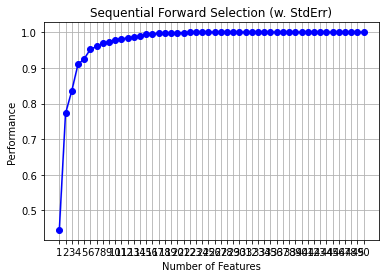

In [11]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
import matplotlib.pyplot as plt
fig1 = plot_sfs(sfs1.get_metric_dict(), kind='std_dev')
plt.title('Sequential Forward Selection (w. StdErr)')
plt.grid()
plt.show()

In [12]:
#optimized number of features shown from the above graph is 15

In [13]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LinearRegression
# Sequential Forward Selection(sfs)
sfs = SFS(LinearRegression(),
          k_features=20,
          forward=True,
          floating=False,
          scoring = 'r2',
          cv = 0)

In [14]:
sfs.fit(X, y)
sfs.k_feature_names_ 

('VisualG',
 'ConclusionPET',
 'ABusepostoper',
 'median_intensity',
 'variance',
 'cluster_prominence_mean',
 'cluster_prominence_max',
 'cluster_tendency_mean',
 'dissimilarity_mean',
 'energy_A',
 'information_measure_of_correlation2_mean',
 'inverse_difference_normalized_mean',
 'inverse_difference_normalized_max',
 'short_run_high_gray_level_emphasis_mean',
 'long_run_low_gray_level_emphasis_mean',
 'gray_level_nonuniformity_A',
 'low_gray_level_zone_emphasis',
 'high_gray_level_zone_emphasis',
 'small_zone_low_gray_level_emphasis',
 'filter_$')